# NIVEL 1

* Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.


In [1]:
# pip install mysql-connector-python
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from configDB import mysql_config

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


In [2]:
def conectar_mysql():
    try:
        conexion = mysql.connector.connect(**mysql_config)
        if conexion.is_connected():
            print("Conexion exitosa a mysql")
            return conexion
    except mysql.connector.Error as error:
        print(f"Error al conectar: {error}")
        return None

conexion = conectar_mysql()

Conexion exitosa a mysql


In [3]:
def obtener_tablas(conexion):
    cursor = conexion.cursor()
    cursor.execute("SHOW TABLES")
    tablas = [tabla[0] for tabla in cursor.fetchall()]
    cursor.close()
    return tablas
obtener_tablas(conexion)

['companies',
 'credit_cards',
 'megatabla',
 'megatabla2',
 'products',
 'products_related',
 'status_cc',
 'transactions',
 'users']

In [4]:
def cargar_todas_tablas(conexion, excluir= None):
    if excluir is None:
        excluir = []
    
    tablas = obtener_tablas(conexion)
    tablas_filtradas = [t for t in tablas if t not in excluir]

    dataframes ={}
    
    print("Tablas a cargar: ")
    for tabla in tablas_filtradas:
        try:
            df = pd.read_sql(f"SELECT * FROM {tabla}", conexion)
            dataframes[tabla] = df
            print(f" {tabla}: {len(df)} filas x {len(df.columns)} columnas")
        except Exception as e:
            print(f" {tabla} ERROR: {str(e)}")

    return dataframes

In [5]:
""" Aplicacion: Carga de todas las tablas de una BD"""
conexion =conectar_mysql()
if not conexion:
    raise RuntimeError("No se pudo conectar la Base de datos")

dfs = cargar_todas_tablas(conexion, excluir=['megatabla', 'megatabla2'])

conexion.close()
print("\n Conexion cerrada")

Conexion exitosa a mysql
Tablas a cargar: 
 companies: 100 filas x 6 columnas
 credit_cards: 5000 filas x 9 columnas
 products: 100 filas x 6 columnas


C:\Users\vanem\AppData\Local\Temp\ipykernel_19696\616967445.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {tabla}", conexion)


 products_related: 253391 filas x 2 columnas
 status_cc: 5000 filas x 2 columnas
 transactions: 100000 filas x 10 columnas
 users: 5000 filas x 11 columnas

 Conexion cerrada


* Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.
* **Recorda**: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.
    * Una variable numèrica.
    * Dues variables numèriques.
    * Una variable categòrica.
    * Una variable categòrica i una numèrica.
    * Dues variables categòriques.
    * Tres variables combinades.
    * Crea un Pairplot.


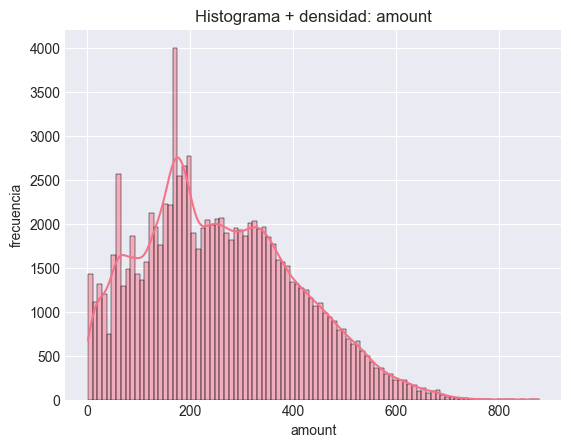

count    100000.000000
mean        259.015312
std         148.539811
min           2.120000
25%         148.910000
50%         244.235000
75%         361.470000
max         876.660000
Name: amount, dtype: float64

In [6]:
"""Una variable numerica"""

def plot_unanumerica(s, col):
    sns.histplot(x=s, kde=True)
    plt.title(f"Histograma + densidad: {col}")
    plt.ylabel('frecuencia')
    plt.savefig(f"hist_density_{col}.png")
    plt.show()

plot_unanumerica(dfs['transactions']['amount'], 'amount')
#sns.displot(data=dfs['transactions']['amount'], kde=True)

dfs['transactions']['amount'].describe()


**Interpretación**
* Histograma muestra una distribución asimétrica hacia la derecha (sesgo positivo). Hay pocas transacciones con importes altos, la mayoria se concentra en importes medios y bajos.
* Según los estadísticos, hay una dispersión alta, bastante variabilidad. El 50% de los datos está por debajo de 244.2, siendo la mediana < media, indicando cola hacia valores altos.


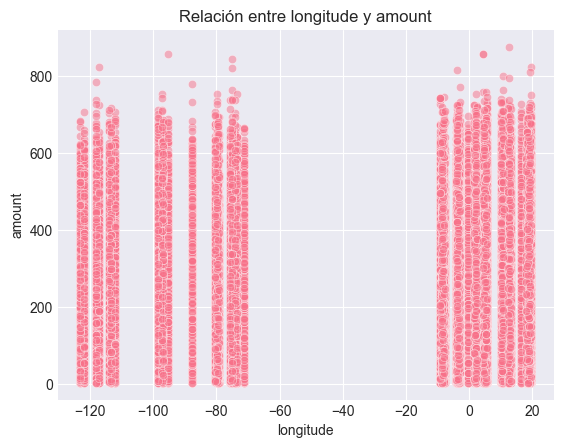

In [7]:
"""Dos variables numericas"""

def plot_dosnumerica(dfs, table_name, x_col, y_col):
    sns.scatterplot(data=dfs[table_name], x=x_col, y=y_col, alpha=0.5)
    plt.title(f'Relación entre {x_col} y {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.savefig(f"scatter_{table_name}_{x_col}_vs_{y_col}.png")
    plt.show()

plot_dosnumerica(dfs,'transactions', 'longitude', 'amount')

#sns.scatterplot(x=dfs['transactions']['longitude'], y=dfs['transactions']['amount'])


**Interpretación**
* Scatterplot muestra que no hay una relación clara entre la longitude y el amount. 
* Los puntos se agrupan en bandas verticales bien separadas, las transacciones están concentradas en unas pocas zonas geográficas.


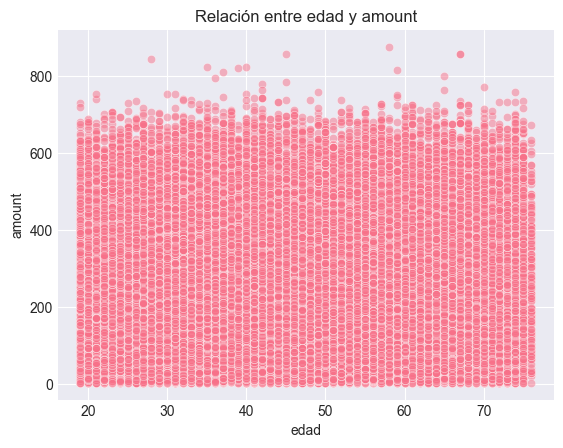

In [8]:
""" Nuevo df: 'transactions_users' """

df_tr_users= dfs['transactions'].merge(dfs['users'][['id', 'birth_date', 'country']], left_on='user_id', right_on='id', suffixes=('', '_user'))
df_tr_users['birth_date'] = pd.to_datetime(df_tr_users['birth_date'], errors= 'coerce')
df_tr_users['edad'] = ((pd.Timestamp.today() - df_tr_users['birth_date']).dt.days / 365.25).astype(int)
df_tr_users['country_code'] = df_tr_users['country'].astype('category').cat.codes
dfs['transactions_users'] = df_tr_users

plot_dosnumerica(dfs,'transactions_users', 'edad', 'amount')


**Interpretación**
* Scatterplot muestra que no hay una relación clara entre la edad y el amount. 
* No se puede establecer que haya grupos de edad que tiendan a gastar más.


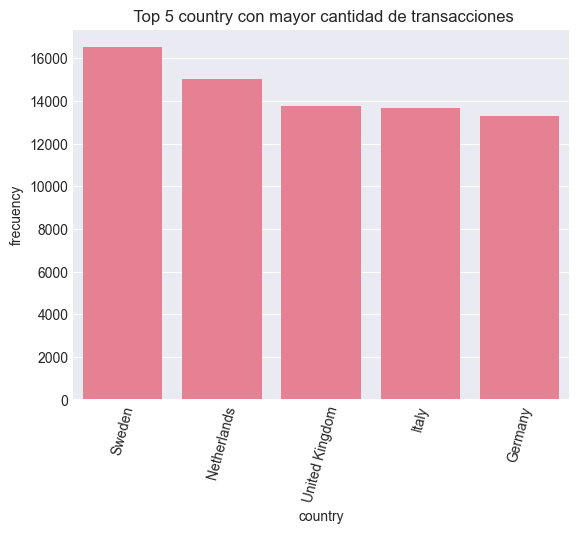

In [9]:
"""Una variable categorica"""

df_tr_company= dfs['transactions'].merge(dfs['companies'][['company_id', 'country']], left_on='business_id', right_on='company_id', how='left')
dfs['transactions_companies'] = df_tr_company

def plot_unacategorica(s, col, top_n):
    freq = s.value_counts().head(top_n)

    sns.barplot(x=freq.index, y=freq.values)
    plt.title(f' Top {top_n} {col} con mayor cantidad de transacciones')
    plt.xlabel(col)
    plt.ylabel('frecuency')
    plt.xticks(rotation=75)
    plt.savefig(f'bar_{col}.png')
    plt.show()

plot_unacategorica(dfs['transactions_companies']['country'], 'country', 5)


**Interpretación**
* Barplot muestra el Top 5 de paises que concentran la mayor cantidad de transacciones realizadas por empresas de dichos paises. 
* Los mercados con mayor volumen son Suecia, Holanda, Reino Unido, Italia y Alemania, respectivamente.

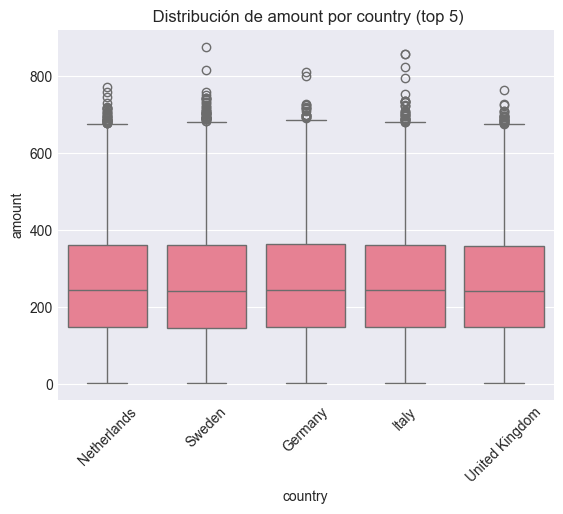

In [10]:
"""Una categorica y una numerica"""

def plot_unacatego_unanumerica(dfs, table_name, cat_col, num_col, top_n):

    df = dfs[table_name][[cat_col, num_col]].dropna()
    top_cats = ( df[cat_col].value_counts().head(top_n).index)
    df_top = df[df[cat_col].isin(top_cats)]

    sns.boxplot(data=df_top, x=cat_col, y=num_col)
    plt.title(f' Distribución de {num_col} por {cat_col} (top {top_n})')
    plt.xlabel(cat_col)
    plt.ylabel(f'{num_col}')
    plt.xticks(rotation=45)
    plt.savefig(f'boxp_{num_col}_por_{cat_col}.png')
    plt.show()

plot_unacatego_unanumerica(dfs, 'transactions_companies', 'country', 'amount', 5)


**Interpretación**
* Boxplot muestra el Top 7 de paises que concentran los mayores importes por transacción realizadas por empresas de dichos paises. 
* Los mercados con mayores importes por transaccion son Holanda, Suecia, Estados Unidos, Alemania, Francia, Italia y Reino Unido, respectivamente.
* Las medianas son similares, por lo que el ticket tipico es similar aunque EEUU tiene un caja ligeramente más alta, la diferencia no es extrema.
* La presencia de outliers en importes altos (arriba de 700-850)en todos los paises, es algo a revisar con mayor profundidad.

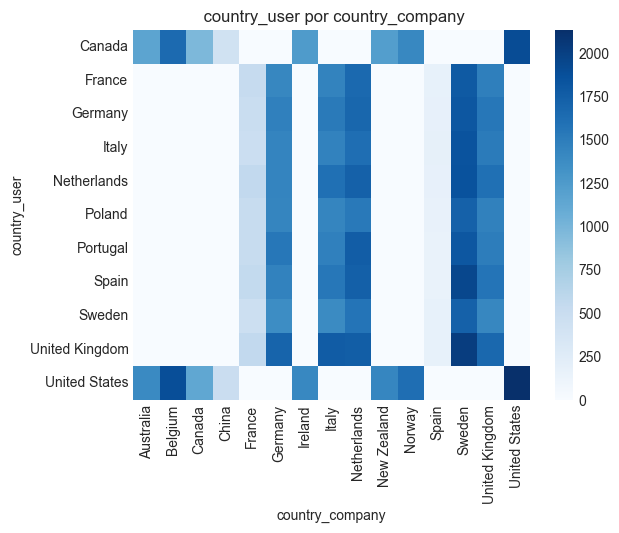

In [11]:
"""Dos variables categoricas"""

# Crear tabla 'transactions_companies_users'
df_tr_comp_users = df_tr_company.merge(dfs['users'][['id','country']], left_on='user_id', right_on='id',suffixes=('','_user'))
dfs['transactions_companies_users'] = df_tr_comp_users

def plot_doscategoricas(dfs, tabla, col_cat1, col_cat2):

    tmp = dfs[tabla]
    ct = pd.crosstab(tmp[col_cat1], tmp[col_cat2])
    sns.heatmap(ct, annot=False, cmap='Blues')

    plt.title(f' {col_cat1} por {col_cat2}_company')
    plt.xlabel(f'{col_cat2}_company')
    plt.ylabel(col_cat1)
    plt.savefig(f'heat_{col_cat1}_por_{col_cat2}.png')
    plt.show()

plot_doscategoricas(dfs, 'transactions_companies_users', 'country_user', 'country')


**Interpretación**
* Heatmap muestra cuantas transacciones hay para cada combinación de país del usuario y país de la empresa. El color de cada celda indica el número de transacciones en dicha combinación, cuanto más oscuro, más transacciones. 
* Hay combinaciones muy oscuras por ejemplo en EEUU, donde se puede afirmar que tiene una economia doméstica fuerte. En otras combinaciones se ve que Alemania,Italia, Suecia y Reino Unido reciben gran volumen de transacciones desde los paises de los usuarios.


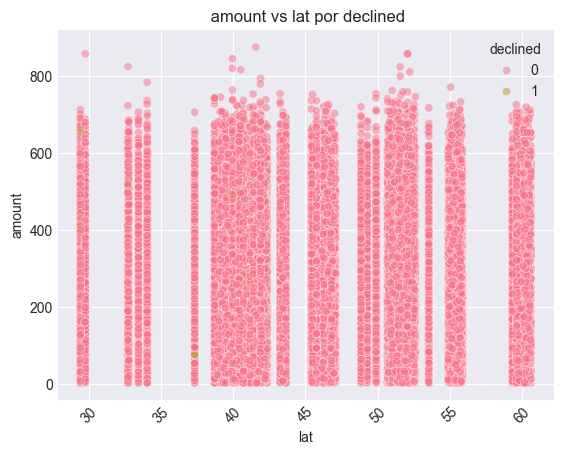

In [12]:
"""Tres variables combinadas"""
def plot_tresvariables(dfs, tabla,col_x, col_y, col_hue):
    sns.scatterplot(data=dfs[tabla], x= col_x, y= col_y,
                hue= col_hue, alpha=0.5)
    plt.title(f' {col_y} vs {col_x} por {col_hue}')
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.xticks(rotation=45)
    plt.legend(title= col_hue)
    plt.savefig(f'scatter_{col_y}_vs_{col_x}_por_{col_hue}.png')
    plt.show()

plot_tresvariables(dfs, 'transactions', 'lat', 'amount', 'declined')


**Interpretación**
* Scatterplot muestra que predomina el color de transacciones aceptadas, casi no se distinguen las transacciones declinadas.
* Por lo que No hay un patrón de que ciertas latitudes tengan más rechazos o que importes muy altos se rechacen más.


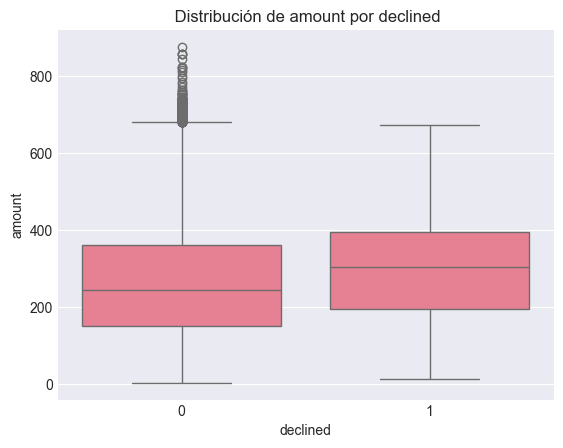

In [13]:
"""Tres variables combinadas"""

def plot_tresvariables(dfs, tabla, col_x, col_y):
    sns.boxplot(data=dfs[tabla], x= col_x, y= col_y)
    
    plt.title(f' Distribución de {col_y} por {col_x}')
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.savefig(f'box3var_{col_y}_por_{col_x}.png')
    plt.show()

plot_tresvariables(dfs, 'transactions', 'declined', 'amount')

**Interpretación**
* En este gráfico se tiene dos variables de entrada: amount (numerica) y declined(categórica/binaria) y se considera como una 3ra dimensión al tipo de estadístico que se muestra (distribución de amount por grupo).
* Las cajas (Q1-Q3) de 'decline'=1 están desplazadas hacia arriba y el 50% central de importes es mayor que en las no declinadas (= 0). Por lo que se puede decir que, las transacciones rechazadas tienen importes algo más altos que las aceptadas.
* El gráfico sugiere que el 'amount' influye en el rechazo, pero hace falta profundizar en ello, ya que existen otuliers superiores a 700 que han sido aceptados.


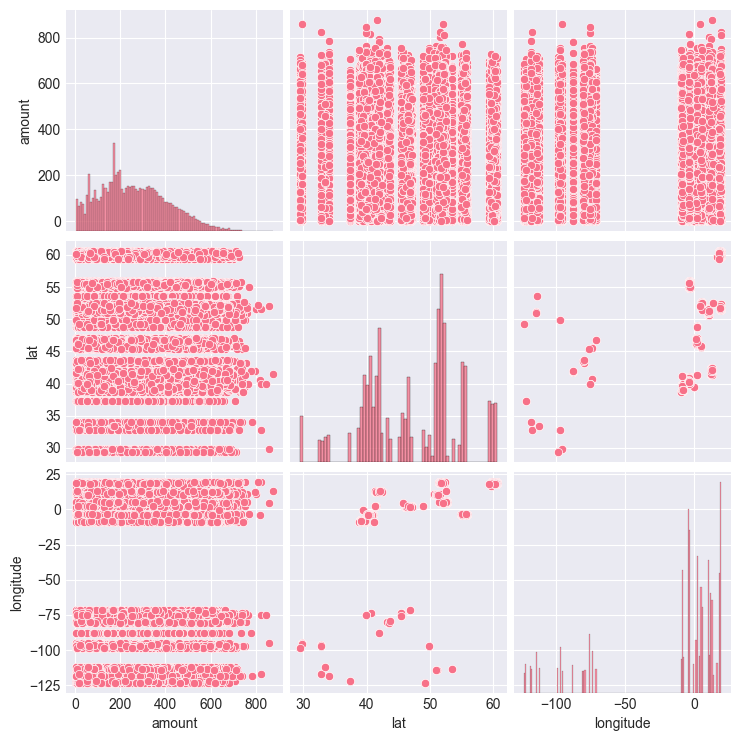

In [14]:
"""Pairplot"""
def plot_pairplot(dfs, tabla, cols):
    sns.pairplot(dfs[tabla][cols].dropna())
    plt.savefig(f'pairplot_{'_'.join(cols)}.png')
    plt.show()

plot_pairplot(dfs, 'transactions', ['amount', 'lat', 'longitude'])


**Interpretación**
* En este gráfico se tiene: Histograma de 'amount', distribución con sesgo positivo; Histograma de 'lat', con valores discretos, que sugiere zonas predefinidas; Histograma de 'longitude', muestra grupos de longitudes.
* En la graficas de 'amount' con 'lat' y 'longitude', se ven nubes horizontales y verticales sin un patrón, lo que indica que No hay relación entre 'amount' con 'lat' y 'longitude'.
* Finalmente, hay una correlacion moderada entre 'lat' y logitude', pero estas solo reflejan los clusteres geográficos de actividad, no el tamaño del 'amount'. El'amount' está desacoplado de las coordenadas geográficas.


# NIVEL 2

* Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

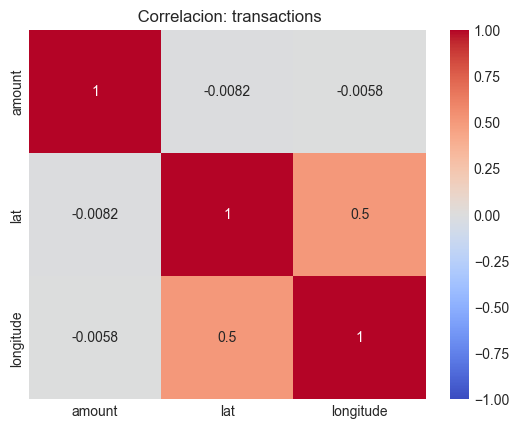

In [15]:
"""Correlacion"""

def corr(dfs, tabla, cols):

    df = dfs[tabla][cols].dropna()
    corr = df.corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f' Correlacion: {tabla}')
    plt.savefig(f'corr_{tabla}_{'_'.join(cols)}.png')
    plt.show()

corr(dfs, 'transactions', ['amount', 'lat', 'longitude'])


**Interpretación**
* No se detecta correlación lineal entre las variables, para el 'amount' la 'latitud' y'longitude' no son variables predictoras, su correlación es casi nula. La relación entre latitud y longitud, tienen una correlación positiva moderada, pero es razonable por ser datos geográficos.

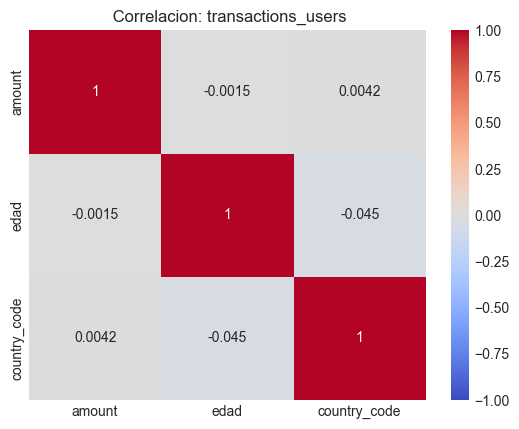

In [16]:
"""Correlacion2"""

def corr(dfs, tabla, cols):

    df = dfs[tabla][cols].dropna()
    corr = df.corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f' Correlacion: {tabla}')
    plt.savefig(f'corr_{tabla}_{'_'.join(cols)}.png')
    plt.show()

corr(dfs, 'transactions_users', ['amount', 'edad', 'country_code'])


**Interpretación**
* No hay correlación lineal entre las variables 'amount', 'edad', y 'country_code', el coeficiente de pearson no detecta correlación lineal.
* Habria que replantear el enfoque de la variable 'edad' para volver a analizar si tiene correlación con 'amount'.

In [17]:
""" Para verificar que los datos estan bien y la ausencia de correlacion es un resultado real"""
# 1. Ver algunas filas
print(df_tr_users[['amount', 'birth_date', 'edad', 'country', 'country_code']].head())

# 2. Tipos de datos
print(df_tr_users[['amount', 'edad', 'country_code']].dtypes)

# 3. Estadísticos básicos
print(df_tr_users[['amount', 'edad', 'country_code']].describe())

   amount birth_date  edad        country  country_code
0  395.43 1996-01-28    29         France             1
1  155.63 1957-08-16    68          Italy             3
2  326.01 1995-09-04    30  United States            10
3  161.60 1969-02-19    56         Canada             0
4  148.91 1961-02-08    64    Netherlands             4
amount          float64
edad              int64
country_code       int8
dtype: object
              amount           edad   country_code
count  100000.000000  100000.000000  100000.000000
mean      259.015312      46.312950       5.108850
std       148.539811      16.228168       3.264513
min         2.120000      19.000000       0.000000
25%       148.910000      32.000000       2.000000
50%       244.235000      45.000000       5.000000
75%       361.470000      60.000000       8.000000
max       876.660000      76.000000      10.000000


* Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

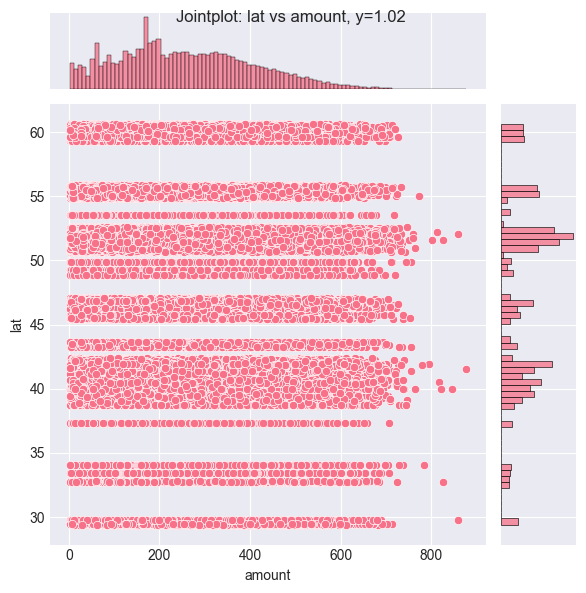

In [18]:
def jointplot_var(dfs, tabla, col_x, col_y, kind='scatter'):
    g = sns.jointplot(data=dfs[tabla], x=col_x, y=col_y, kind=kind)
    g.figure.suptitle(f'Jointplot: {col_y} vs {col_x}, y=1.02')
    g.figure.savefig(f'joint_{tabla}_{col_y}_vs_{col_x}.png')
    plt.show()

jointplot_var(dfs, 'transactions', 'amount', 'lat')

**Interpretación**
* Jointplot muestra que no hay una relación entre el 'amount' de la ransacción y la 'latitud' donde se realizan. El gráfico central: muestra que los puntos forman bandas horizontales, no hay patrón creciente o decreciente por latitud.

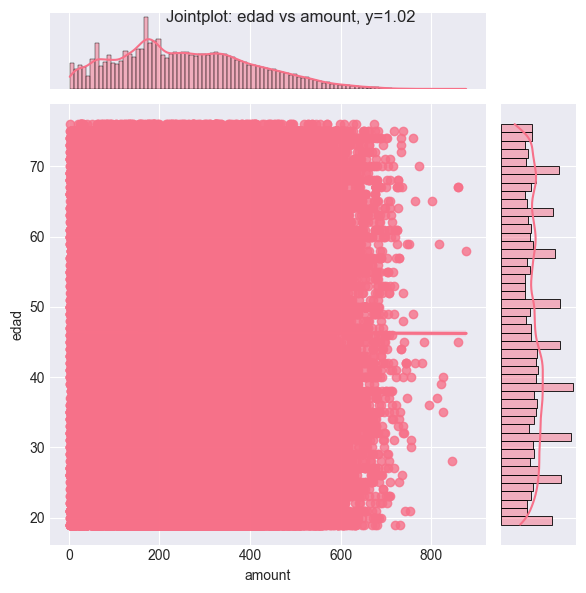

In [19]:
jointplot_var(dfs, 'transactions_users', 'amount', 'edad', kind='reg')

**Interpretación**
* Jointplot muestra que no hay una relación entre el 'amount' de la ransacción y la 'edad' de los usuarios. El grafico central: muestra que los puntos forman un rectángulo denso, usuarios de todas las edades , hacen transacciones en todos los rangos; por lo que se ve que la edad no influye el aumento o disminución del 'amount'.
* No obstante, si se aborda de otra manera la variable 'edad' es posible que se refleje algun patrón (par lo cual habrá que profundizar).

# NIVEL 3

* Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.
* **Recorda:** quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.